# Plant Disease Classification

**Automated identification of plant diseases from leaf images using deep learning.**

This notebook will cover:
1. **Environment Setup** Clone the repository and install dependencies
2. **Kaggle API Configuration** Authenticate and configure dataset access
3. **Dataset Preparation** Download, extract, and organize the dataset
4. **Model Training** Train and compare ResNet-18, ResNet-50, and EfficientNet-B0
5. **Inference** Run predictions on the held-out test set

## 1. Environment Setup

Clone the project repository, set drive repository, connect drive and local directory for model results, and install all required Python packages.

In [1]:
from google.colab import drive
import os, shutil

drive.mount('/content/drive')

repo_root = "/content/PlantDiseasePredictionNN"
repo_outputs = f"{repo_root}/outputs"
drive_outputs = "/content/drive/MyDrive/PlantDiseasePredictionNN_outputs"

Mounted at /content/drive


In [2]:
# Clone the project repository
!git clone https://github.com/StefanLazarevic02/PlantDiseasePredictionNN
%cd PlantDiseasePredictionNN

Cloning into 'PlantDiseasePredictionNN'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 83 (delta 33), reused 74 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 8.08 MiB | 25.94 MiB/s, done.
Resolving deltas: 100% (33/33), done.
/content/PlantDiseasePredictionNN


In [3]:
if os.path.islink(repo_outputs) or os.path.exists(repo_outputs):
    try:
        os.remove(repo_outputs)
    except:
        shutil.rmtree(repo_outputs)

os.symlink(drive_outputs, repo_outputs)

print("OK:")
print(f"{repo_outputs} -> {drive_outputs}")

OK:
/content/PlantDiseasePredictionNN/outputs -> /content/drive/MyDrive/PlantDiseasePredictionNN_outputs


In [4]:
# Install all required packages
!pip install -q torch torchvision albumentations Pillow numpy pandas \
    matplotlib seaborn scikit-learn PyYAML tqdm opencv-python kaggle imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.0 MB/s eta 0:00:00


## 2. Kaggle API Configuration

Upload your `kaggle.json` credentials file and configure the Kaggle CLI for dataset downloads.

In [5]:
# Upload kaggle.json credentials
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "stefanlazarevic02",\r\n  "key": "KGAT_a86d048c2a6fe11726b46fb124b435b2"\r\n}'}

In [6]:
# Set up Kaggle credentials directory and permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## 3. Dataset Download & Preparation

Download the [New Plant Diseases Dataset](https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset) from Kaggle, extract it, and reorganize the test split into the correct directory structure.

In [7]:
# Download and extract the dataset
!kaggle datasets download -d 'vipoooool/new-plant-diseases-dataset'
!unzip -q new-plant-diseases-dataset.zip -d data/

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:19<00:00, 146MB/s]



In [8]:
# Reorganize directory structure: move test split and clean up duplicates
%cd data
!rm -rf "new plant diseases dataset(augmented)"
!mv "test/test" "New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/"
!rm -rf "test"
%cd ..

/content/PlantDiseasePredictionNN/data
/content/PlantDiseasePredictionNN


## 4. Model Training

Train three architectures (**ResNet-18**, **ResNet-50**, **EfficientNet-B0**, **VGG16**) with identical hyperparameters and compare their validation accuracy. Each model uses:
- **Optimizer:** AdamW with weight decay
- **Scheduler:** ReduceLROnPlateau
- **Loss:** Weighted CrossEntropy (to handle class imbalance)
- **Augmentation:** Medium policy (rotation, flips, color jitter, noise)


In [9]:
import os

os.environ['PYTHONHASHSEED'] = '42'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import yaml, torch, json, random, datetime
import numpy as np
from src.preprocessing.dataset_analyzer import DatasetAnalyzer
from src.augmentation.policies import get_train_transforms, get_valid_transforms
from src.preprocessing.dataloader import create_dataloaders
from src.models.classifier import create_model
from src.training.trainer import Trainer
from src.utils import set_seed

set_seed(42)

def train_and_record(model_name, config, loaders, device):
    """Train a single model, save its history, and return result metrics"""
    print(f"\n{'='*60}\nTRAINING: {model_name.upper()}\n{'='*60}")
    set_seed(42)

    model = create_model(
        num_classes=config["dataset"].get("num_classes", 38),
        model_name=model_name, pretrained=True,
    )
    save_dir = f"outputs/{model_name}"
    os.makedirs(save_dir, exist_ok=True)

    trainer = Trainer(
        model=model, train_loader=loaders["train"],
        valid_loader=loaders["valid"], config=config, device=device,
    )
    history = trainer.train(save_dir=save_dir)

    with open(f"{save_dir}/training_history.json", "w") as f:
        json.dump(history, f, indent=2)

    return {
        "model_name": model_name,
        "best_accuracy": max(history["valid_acc"]),
        "final_train_acc": history["train_acc"][-1],
        "final_valid_acc": history["valid_acc"][-1],
        "history": history,
    }

# Device selection
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if device == "cuda" else ""))
all_results = []


Seed set to 42
  - PYTHONHASHSEED: 42
  - torch.backends.cudnn.deterministic: True
  - torch.backends.cudnn.benchmark: False
  - torch.use_deterministic_algorithms: True
  - Albumentations seed: 42
  - CUBLAS_WORKSPACE_CONFIG: :4096:8
Device: cuda (Tesla T4)


### Trening pipeline (single-model run)

- Postavlja **reproducibilnost** kroz `set_seed(SEED=42)`.
- Funkcija `train_and_record(model_name, config, loaders, device)`:
  - kreira model (`pretrained=True`, broj klasa iz `config`),
  - pokrece trening preko `Trainer`,
  - cuva istoriju treninga u `outputs/<model_name>/training_history.json`,
  - vraca kljucne metrike (`best_accuracy`, finalni train/valid accuracy).

> Napomena: Za `vgg16` finalni klasifikacioni sloj je `model.classifier[6]`, ne `model.fc`.

### 4.1 Load Config, Compute Statistics & Create DataLoaders

Read the YAML config, optionally compute per-channel mean/std from the training set, build albumentations transforms, and create PyTorch DataLoaders with weighted sampling to counter class imbalance.

In [10]:
# Load config
with open("config/config.yaml") as f:
    config = yaml.safe_load(f)

# Compute dataset-level statistics if enabled
ds_cfg = config["dataset"]
analyzer = DatasetAnalyzer(ds_cfg["root_dir"], ds_cfg.get("train_dir", "train"), ds_cfg.get("valid_dir", "valid"))

if config["preprocessing"].get("use_dataset_stats", False):
    stats = analyzer.compute_dataset_stats()
    config["dataset"]["mean"], config["dataset"]["std"] = stats["mean"], stats["std"]

# Build augmentation transforms
policy = config["augmentation"].get("policy", "medium")
train_transform = get_train_transforms(config, policy=policy)
valid_transform = get_valid_transforms(config)

# Create dataloaders
loaders = create_dataloaders(
    config=config,
    train_transform=train_transform,
    valid_transform=valid_transform,
    use_weighted_sampling=True,
    seed=42
)
print(f"Train batches: {len(loaders['train'])} | Valid batches: {len(loaders['valid'])}")

Calculating mean/std of dataset


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Computing stats:   0%|          | 0/1099 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number

Dataset Mean: [0.4757, 0.5001, 0.4264]
Dataset Std:  [0.2165, 0.1957, 0.2320]
Loaded 70295 pictures from 38 classes (data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train)
Loaded 17572 pictures from 38 classes (data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid)
Loaded 0 pictures from 0 classes (data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/test)
Train batches: 1098 | Valid batches: 275


Dataset stats su uspijesno izracunate i primenjene (mean/std), augmentacije i dataloader-i su kreirani. Train/valid skupovi su učitani (70,295 / 17,572 slika, 38 klasa), test je trenutno prazan (jer se ne ucitava za treniranje).

### 4.2 Train ResNet-18

A lightweight 18-layer residual network. This model is fast to train and a good baseline for comparison.

In [ ]:
all_results.append(train_and_record("resnet18", config, loaders, device))


TRAINING: RESNET18
Seed set to 42
  - PYTHONHASHSEED: 42
  - torch.backends.cudnn.deterministic: True
  - torch.backends.cudnn.benchmark: False
  - torch.use_deterministic_algorithms: True
  - Albumentations seed: 42
  - CUBLAS_WORKSPACE_CONFIG: :4096:8
Creating model: resnet18 (pretrained=True)
Total parameters: 11,196,006
Trainable parameters: 11,196,006
Using device: cuda

STARTING TRAINING
Epochs: 8
Learning rate: 0.001
Batch size: 64
Train samples: 70,295
Valid samples: 17,572

Epoch 1/8
----------------------------------------


Train Loss: 0.2717 | Train Acc: 91.60%
Valid Loss: 0.1395 | Valid Acc: 95.31%
New best model saved! (Acc: 95.31%)

Epoch 2/8
----------------------------------------


Train Loss: 0.1248 | Train Acc: 95.95%
Valid Loss: 0.0726 | Valid Acc: 97.57%
New best model saved! (Acc: 97.57%)

Epoch 3/8
----------------------------------------


Train Loss: 0.0969 | Train Acc: 96.87%
Valid Loss: 0.0915 | Valid Acc: 97.11%

Epoch 4/8
----------------------------------------


Train Loss: 0.0895 | Train Acc: 97.11%
Valid Loss: 0.0577 | Valid Acc: 98.07%
New best model saved! (Acc: 98.07%)

Epoch 5/8
----------------------------------------


Train Loss: 0.0721 | Train Acc: 97.69%
Valid Loss: 0.1183 | Valid Acc: 96.79%

Epoch 6/8
----------------------------------------


Train Loss: 0.0638 | Train Acc: 97.91%
Valid Loss: 0.0564 | Valid Acc: 98.22%
New best model saved! (Acc: 98.22%)

Epoch 7/8
----------------------------------------


Train Loss: 0.0600 | Train Acc: 98.00%
Valid Loss: 0.0439 | Valid Acc: 98.49%
New best model saved! (Acc: 98.49%)

Epoch 8/8
----------------------------------------


Train Loss: 0.0557 | Train Acc: 98.20%
Valid Loss: 0.0306 | Valid Acc: 98.92%
New best model saved! (Acc: 98.92%)

TRAINING COMPLETED!
Total time: 37.7 minutes
Best validation accuracy: 98.92%


### Trening ResNet18 modela

- Preuzeti su pretrained ImageNet tezinski parametri (`resnet18-f37072fd.pth`).

### Rezultati po epohama
- **Epoch 1:** Train Acc 91.60% | Valid Acc 95.31%
- **Epoch 2:** Train Acc 95.95% | Valid Acc 97.57%
- **Epoch 3:** Train Acc 96.67% | Valid Acc 97.11%
- **Epoch 4:** Train Acc 97.11% | Valid Acc 98.07%
- **Epoch 5:** Train Acc 97.69% | Valid Acc 96.79%
- **Epoch 6:** Train Acc 97.91% | Valid Acc 98.22%
- **Epoch 7:** Train Acc 98.00% | Valid Acc 98.49%
- **Epoch 8:** Train Acc 98.20% | Valid Acc **98.92%**- Ovo je najbolji
rezultat koji ce biti koriscen za testiranje.

### Zakljucak
Model je konvergirao stabilno i postigao vrlo visoku tacnost.
- **Best validation accuracy:** **98.92%**
- **Ukupno vreme treninga:** ~37.7 min

### 4.3 Train ResNet-50

A deeper 50-layer residual network with bottleneck blocks. This model has higher capacity but takes longer to train.

In [11]:
all_results.append(train_and_record("resnet50", config, loaders, device))


TRAINING: RESNET50
Seed set to 42
  - PYTHONHASHSEED: 42
  - torch.backends.cudnn.deterministic: True
  - torch.backends.cudnn.benchmark: False
  - torch.use_deterministic_algorithms: True
  - Albumentations seed: 42
  - CUBLAS_WORKSPACE_CONFIG: :4096:8
Creating model: resnet50 (pretrained=True)
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]


Total parameters: 23,585,894
Trainable parameters: 23,585,894
Using device: cuda

STARTING TRAINING
Epochs: 8
Learning rate: 0.001
Batch size: 64
Train samples: 70,295
Valid samples: 17,572

Epoch 1/8
----------------------------------------


Train Loss: 0.2123 | Train Acc: 93.63%
Valid Loss: 0.0843 | Valid Acc: 97.18%
New best model saved! (Acc: 97.18%)

Epoch 2/8
----------------------------------------


Train Loss: 0.0777 | Train Acc: 97.48%
Valid Loss: 0.1337 | Valid Acc: 96.12%

Epoch 3/8
----------------------------------------


...

Train Loss: 0.0515 | Train Acc: 98.32%
Valid Loss: 0.0453 | Valid Acc: 98.48%
New best model saved! (Acc: 98.48%)

Epoch 5/8
----------------------------------------


Train Loss: 0.0412 | Train Acc: 98.59%
Valid Loss: 0.0222 | Valid Acc: 99.27%
New best model saved! (Acc: 99.27%)

Epoch 6/8
----------------------------------------


Train Loss: 0.0411 | Train Acc: 98.69%
Valid Loss: 0.0340 | Valid Acc: 98.98%

Epoch 7/8
----------------------------------------


Train Loss: 0.0345 | Train Acc: 98.89%
Valid Loss: 0.0303 | Valid Acc: 99.10%

Epoch 8/8
----------------------------------------


Train Loss: 0.0330 | Train Acc: 98.91%
Valid Loss: 0.0336 | Valid Acc: 98.84%

TRAINING COMPLETED!
Total time: 122.8 minutes
Best validation accuracy: 99.27%


### Trening ResNet50 modela

### Rezultati po epohama
- **Epoch 1:** Train 93.63% | Valid 97.18%  
- **Epoch 2:** Train 97.48% | Valid 96.12%
- **Epoch 3:** Train 97.97% | Valid 98.38%  
- **Epoch 4:** Train 98.32% | Valid 98.48%
- **Epoch 5:** Train 98.59% | Valid **99.27%** - Ovo je najbolji rezultat koji ce biti koriscen za testiranje.
- **Epoch 6:** Train 98.69% | Valid 98.98%
- **Epoch 7:** Train 98.89% | Valid 99.10%
- **Epoch 8:** Train 98.91% | Valid 98.84%

### Zakljucak
- **Best validation accuracy:** **99.27%**
- **Ukupno vrijeme treninga:** ~**122.8 min**

### 4.4 Train EfficientNet-B0

A compact architecture that uses compound scaling for width, depth, and resolution. This model typically achieves strong accuracy with fewer parameters.

In [ ]:
all_results.append(train_and_record("efficientnet_b0", config, loaders, device))


TRAINING: EFFICIENTNET_B0
Seed set to 42
  - PYTHONHASHSEED: 42
  - torch.backends.cudnn.deterministic: True
  - torch.backends.cudnn.benchmark: False
  - torch.use_deterministic_algorithms: True
  - Albumentations seed: 42
  - CUBLAS_WORKSPACE_CONFIG: :4096:8
Creating model: efficientnet_b0 (pretrained=True)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 67.7MB/s]


Total parameters: 4,056,226
Trainable parameters: 4,056,226
Using device: cuda

STARTING TRAINING
Epochs: 8
Learning rate: 0.001
Batch size: 64
Train samples: 70,295
Valid samples: 17,572

Epoch 1/8
----------------------------------------


Train Loss: 0.1942 | Train Acc: 94.37%
Valid Loss: 0.0826 | Valid Acc: 97.52%
New best model saved! (Acc: 97.52%)

Epoch 2/8
----------------------------------------


Train Loss: 0.0712 | Train Acc: 97.75%
Valid Loss: 0.0305 | Valid Acc: 99.07%
New best model saved! (Acc: 99.07%)

Epoch 3/8
----------------------------------------


...

Train Loss: 0.0470 | Train Acc: 98.48%
Valid Loss: 0.0248 | Valid Acc: 99.21%
New best model saved! (Acc: 99.21%)

Epoch 5/8
----------------------------------------


Train Loss: 0.0416 | Train Acc: 98.69%
Valid Loss: 0.0172 | Valid Acc: 99.48%
New best model saved! (Acc: 99.48%)

Epoch 6/8
----------------------------------------


Train Loss: 0.0393 | Train Acc: 98.77%
Valid Loss: 0.0236 | Valid Acc: 99.29%

Epoch 7/8
----------------------------------------


Train Loss: 0.0373 | Train Acc: 98.80%
Valid Loss: 0.0224 | Valid Acc: 99.32%

Epoch 8/8
----------------------------------------


Train Loss: 0.0339 | Train Acc: 98.89%
Valid Loss: 0.0179 | Valid Acc: 99.40%

TRAINING COMPLETED!
Total time: 56.3 minutes
Best validation accuracy: 99.48%


### Trening EfficientNet-B0 modela

### Rezultati po epochama
- **Epoch 1:** Train Acc 94.37% | Valid Acc 97.52%
- **Epoch 2:** Train Acc 97.75% | Valid Acc 99.07%
- **Epoch 3:** Train Acc 98.09% | Valid Acc 98.99%
- **Epoch 4:** Train Acc 98.48% | Valid Acc 99.21%
- **Epoch 5:** Train Acc 98.69% | Valid Acc **99.48%** - Ovo je najbolji rezultat koji ce biti koriscen za testiranje.
- **Epoch 6:** Train Acc 98.77% | Valid Acc 99.29%
- **Epoch 7:** Train Acc 98.80% | Valid Acc 99.32%
- **Epoch 8:** Train Acc 98.89% | Valid Acc 99.40%

### Zakljucak
- Model je brzo i stabilno konvergirao.
- Sa znatno manjim brojem parametara od ResNet50, postigao je **najbolji rezultat do sada**.
- **Best validation accuracy:** **99.48%**
- **Ukupno vrijeme treninga:** ~**56.3 min**

### 4.5 Train VGG16

A classic 16-layer convolutional network built from stacked 3x3 convolutions and max-pooling. It has more parameters and no residual skips, so it trains slower and can overfit without regularization, making it a solid non-residual baseline for comparison.

In [ ]:
all_results.append(train_and_record("vgg16", config, loaders, device))


TRAINING: VGG16
Creating model: vgg16 (pretrained=True)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 65.5MB/s]


Total parameters: 134,416,230
Trainable parameters: 134,416,230
Using device: cuda

STARTING TRAINING
Epochs: 4
Learning rate: 0.001
Batch size: 64
Train samples: 70,295
Valid samples: 17,572

Epoch 1/4
----------------------------------------


Train Loss: 2.1104 | Train Acc: 37.45%
Valid Loss: 1.0291 | Valid Acc: 67.91%
New best model saved! (Acc: 67.91%)

Epoch 2/4
----------------------------------------


Train Loss: 1.0269 | Train Acc: 67.18%
Valid Loss: 0.5721 | Valid Acc: 81.09%
New best model saved! (Acc: 81.09%)

Epoch 3/4
----------------------------------------


Train Loss: 0.7283 | Train Acc: 76.85%
Valid Loss: 0.5678 | Valid Acc: 81.96%
New best model saved! (Acc: 81.96%)

Epoch 4/4
----------------------------------------


Train Loss: 0.6081 | Train Acc: 80.91%
Valid Loss: 0.4076 | Valid Acc: 87.12%
New best model saved! (Acc: 87.12%)

TRAINING COMPLETED!
Total time: 75.5 minutes
Best validation accuracy: 87.12%


### Trening VGG16 modela

### Rezultati po epohama

- **Epoch 1:** Train 37.45% | Valid 67.91%
- **Epoch 2:** Train 67.18% | Valid 81.09%
- **Epoch 3:** Train 76.85% | Valid 81.96%
- **Epoch 4:** Train 80.91% | Valid 87.12%
- **Epoch 5:** Train 82.95% | Valid 89.57%
- **Epoch 6:** Train 84.52% | Valid 90.43%
- **Epoch 7:** Train 85.54% | Valid 86.84%
- **Epoch 8:** Train 85.74% | Valid **92.05%** - Ovo je najbolji rezultat koji ce biti koriscen za testiranje.

### Zakljucak
- VGG16 pokazuje stabilan napredak kroz duži trening.
- Konacno najbolja validaciona tacnost nakon nastavka: **92.05%**.
- VGG16 je i dalje slabiji od ResNet/EfficientNet modela u ovom eksperimentu.
- **Ukupno vrijeme treninga:** ~**154.5 min**

## 5. Inference on Test Set

Load the best saved checkpoint and run predictions on every image in the test directory. Results are printed per-image and visualized in a grid.

In [ ]:
import torch, yaml, cv2, os, json
import albumentations as A
from albumentations.pytorch import ToTensorV2
from src.models.classifier import create_model

MODELS = ["resnet18", "resnet50", "efficientnet_b0", "vgg16"]

def load_model(model_name, config, device):
    """Load a best trained model checkpoint"""
    model_path = f"outputs/{model_name}/best_model.pth"
    if not os.path.exists(model_path):
        print(f"Model not found: {model_path}")
        return None, None
    checkpoint = torch.load(model_path, map_location=device)
    print(f"{model_name} loaded (val acc: {checkpoint['best_acc']:.2f}%)")
    model = create_model(num_classes=config["dataset"].get("num_classes", 38),
                         model_name=model_name, pretrained=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device).eval()
    return model, checkpoint['best_acc']

def predict_image(model, image_tensor, class_names):
    """Run inference on a single image tensor"""
    with torch.no_grad():
        probs = torch.softmax(model(image_tensor), dim=1)
        confidence, pred_idx = probs.max(1)
    return class_names[pred_idx.item()], confidence.item() * 100

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


### Ucitavanje modela i inferencija

Ova celija priprema funkcije za evaluaciju treniranih modela (`resnet18`, `resnet50`, `efficientnet_b0`, `vgg16`):

- `load_model(model_name, config, device)`  
  Ucitava `best_model.pth` iz `outputs/<model_name>/`, rekonstruise arhitekturu (`pretrained=False`), ucitava tezine i postavlja model u `eval()` mod.

### 5.1 Load Config, Transforms & Models

Read the config again, build the test-time transform (resize and normalize, no augmentation), load class names from the training directory, collect test images, and load all trained checkpoints into eval mode.

In [ ]:
# Load config
with open("config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Test transform (no augmentation — only resize + normalize)
test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=config["dataset"].get("mean", [0.485, 0.456, 0.406]),
        std=config["dataset"].get("std", [0.229, 0.224, 0.225]),
    ),
    ToTensorV2(),
])

# Class names from training directory
train_path = os.path.join(config["dataset"]["root_dir"], "train")
class_names = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])
print(f"Number of classes: {len(class_names)}\n")

# Collect test images
test_path = os.path.join(config["dataset"]["root_dir"], "test")
test_images = [f for f in os.listdir(test_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f"Test images: {len(test_images)}\n")

# Load all trained models
models, val_accuracies = {}, {}
for name in MODELS:
    m, acc = load_model(name, config, device)
    if m is not None:
        models[name], val_accuracies[name] = m, acc

assert models, "No models loaded!"

Number of classes: 38

Test images: 33

resnet18 loaded (val acc: 98.16%)
Creating model: resnet18 (pretrained=False)
Total parameters: 11,196,006
Trainable parameters: 11,196,006
resnet50 loaded (val acc: 99.04%)
Creating model: resnet50 (pretrained=False)
Total parameters: 23,585,894
Trainable parameters: 23,585,894
efficientnet_b0 loaded (val acc: 99.31%)
Creating model: efficientnet_b0 (pretrained=False)
Total parameters: 4,056,226
Trainable parameters: 4,056,226
vgg16 loaded (val acc: 92.05%)
Creating model: vgg16 (pretrained=False)
Total parameters: 134,416,230
Trainable parameters: 134,416,230


### Priprema za test inferenciju

- Ucitana je konfiguracija i definisan `test_transform` (**Resize 224×224 + Normalize + ToTensorV2**, bez augmentacije).
- Uspijesno su ucitana 4 trenirana modela i njihove najbolje validacione tacnosti:
  - **resnet18:** 98.16%
  - **resnet50:** 99.04%
  - **efficientnet_b0:** 99.31%
  - **vgg16:** 92.05%

### 5.2 Run Predictions on All Test Images

For each test image, run inference through all models and print the predicted class with confidence. Also check whether all models agree on the same prediction.

In [ ]:
print(f"{'='*80}\nPREDICTIONS ON ALL MODELS\n{'='*80}\n")

all_results = []
for img_name in test_images:
    img_path = os.path.join(test_path, img_name)
    image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    input_tensor = test_transform(image=image)["image"].unsqueeze(0).to(device)

    predictions = {}
    print(f"{img_name}")
    for model_name, model in models.items():
        pred_class, conf = predict_image(model, input_tensor, class_names)
        predictions[model_name] = {"class": pred_class, "confidence": conf}
        print(f"   {model_name:<18} → {pred_class} ({conf:.1f}%)")

    unique = set(p["class"] for p in predictions.values())
    print("All models agree!" if len(unique) == 1 else "Models disagree!")
    print()

    all_results.append({
        "image": img_name,
        "predictions": predictions,
        "agreement": len(unique) == 1,
    })

PREDICTIONS ON ALL MODELS

CornCommonRust2.JPG
   resnet18           → Corn_(maize)___Common_rust_ (100.0%)
   resnet50           → Corn_(maize)___Common_rust_ (100.0%)
   efficientnet_b0    → Corn_(maize)___Common_rust_ (100.0%)
   vgg16              → Corn_(maize)___Common_rust_ (64.3%)
All models agree!

TomatoYellowCurlVirus3.JPG
   resnet18           → Tomato___Tomato_Yellow_Leaf_Curl_Virus (100.0%)
   resnet50           → Tomato___Tomato_Yellow_Leaf_Curl_Virus (98.6%)
   efficientnet_b0    → Tomato___Tomato_Yellow_Leaf_Curl_Virus (100.0%)
   vgg16              → Tomato___Tomato_Yellow_Leaf_Curl_Virus (65.9%)
All models agree!

PotatoEarlyBlight3.JPG
   resnet18           → Potato___Early_blight (97.7%)
   resnet50           → Potato___Early_blight (97.5%)
   efficientnet_b0    → Potato___Early_blight (75.9%)
   vgg16              → Apple___Apple_scab (75.2%)
Models disagree!

TomatoEarlyBlight2.JPG
   resnet18           → Tomato___Late_blight (35.5%)
   resnet50           → Tomat

### Zakljucak

- **ResNet18, ResNet50 i EfficientNet-B0** su uglavnom konzistentni i sa vrlo visokim confidence skorovima (cesto 99–100%).
- **EfficientNet-B0** deluje najstabilnije, sto je u skladu sa najboljim `valid acc` tokom treninga (**99.31%**).
- **VGG16** najcesce odstupa od ostalih modela i ima vise pogresnih klasa, sto potvrdjuje da je slabiji u ovom setup-u.
- Neslaganja se najvise javljaju kod vizuelno slicnih bolesti (npr. *Early blight / Late blight / Septoria*).

### 5.3 Statistics & Save Results

Calculate the model agreement rate (how often all models predict the same class), display validation accuracies, and save the full results to `outputs/test_all_models_results.json`.

In [ ]:
# Agreement statistics
agreements = sum(1 for r in all_results if r["agreement"])
print(f"{'='*80}\n  STATISTICS\n{'='*80}")
print(f"\nModel agreement rate: {agreements}/{len(all_results)} ({100*agreements/len(all_results):.1f}%)")

print(f"\nValidation accuracy:")
for name, acc in val_accuracies.items():
    print(f"{name:<18}: {acc:.2f}%")

# Save results to JSON
with open("outputs/test_all_models_results.json", "w") as f:
    json.dump({
        "models": list(models.keys()),
        "val_accuracies": val_accuracies,
        "results": all_results,
        "agreement_rate": agreements / len(all_results),
    }, f, indent=2)

print(f"\nResults saved: outputs/test_all_models_results.json")

  STATISTICS

Model agreement rate: 19/33 (57.6%)

Validation accuracy:
resnet18          : 98.16%
resnet50          : 99.04%
efficientnet_b0   : 99.31%
vgg16             : 92.05%

Results saved: outputs/test_all_models_results.json


### Statistika testiranja

- **Agreement rate:** **19/33** = **57.6%**
- Najbolji validacioni rezultat ima **EfficientNet-B0 (99.31%)**, zatim **ResNet50 (99.04%)** i **ResNet18 (98.16%)**.
- **VGG16 (92.05%)** je najslabiji i najvise doprinosi neslaganjima modelima.

### 5.4 Per-class metrics (recall/F1) and confusion matrix

Compute precision/recall/F1 and the confusion matrix for each model (`best_model.pth`).

Loaded 70295 pictures from 38 classes (data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train)
Loaded 17572 pictures from 38 classes (data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid)
Loaded 0 pictures from 0 classes (data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/test)
Creating model: resnet18 (pretrained=False)
Total parameters: 11,196,006
Trainable parameters: 11,196,006
[LOAD] resnet18 (best_acc: 98.16%)

------------- RESNET18 -------------
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9524    0.9921    0.9718       504
                                 Apple___Black_rot     0.9940    0.9920    0.9930       497
                          Apple___Cedar_apple_rust     1.0000    0.9500    0.9744       440
                                   Apple___healthy     0.9722    0.9741    0.

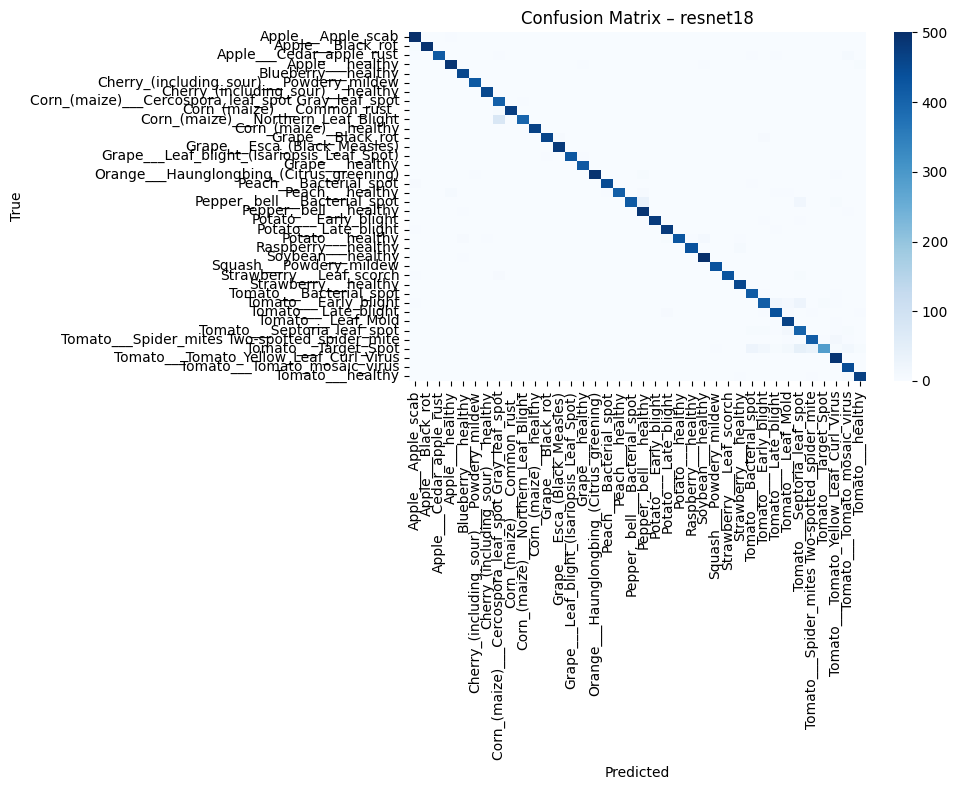

Creating model: resnet50 (pretrained=False)
Total parameters: 23,585,894
Trainable parameters: 23,585,894
[LOAD] resnet50 (best_acc: 99.04%)

------------- RESNET50 -------------
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9821    0.9910       504
                                 Apple___Black_rot     0.9919    0.9799    0.9858       497
                          Apple___Cedar_apple_rust     0.9864    0.9909    0.9887       440
                                   Apple___healthy     0.9958    0.9402    0.9672       502
                               Blueberry___healthy     0.9827    1.0000    0.9913       454
          Cherry_(including_sour)___Powdery_mildew     0.9859    1.0000    0.9929       421
                 Cherry_(including_sour)___healthy     0.9913    1.0000    0.9956       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.7752    0.9927    0.8706   

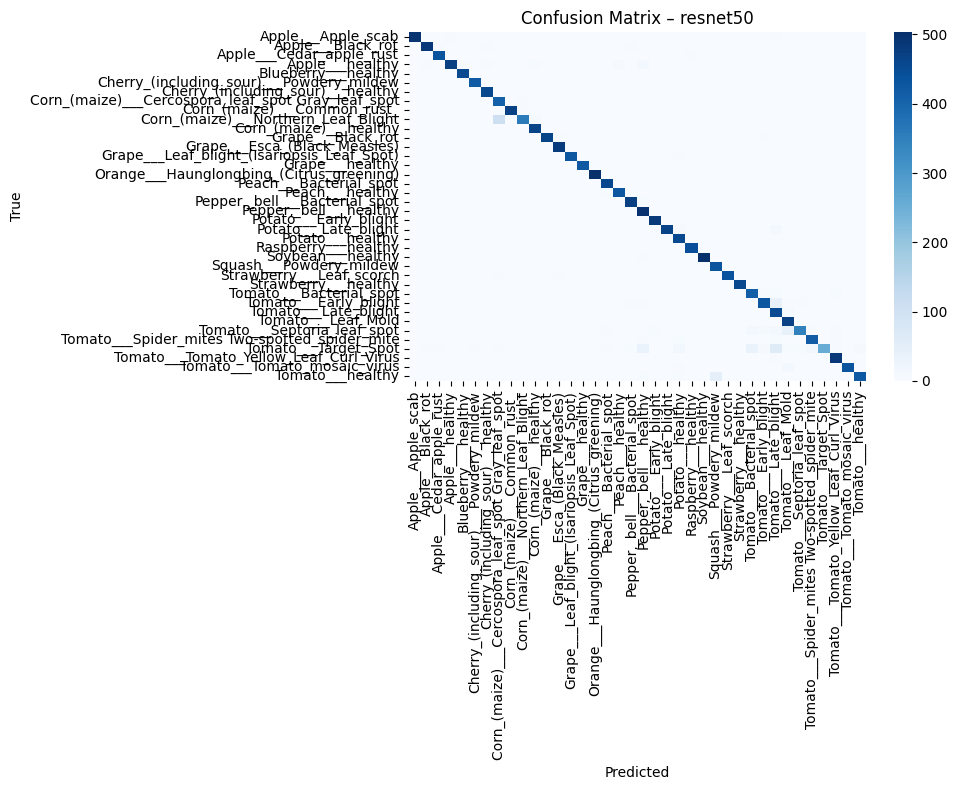

Creating model: efficientnet_b0 (pretrained=False)
Total parameters: 4,056,226
Trainable parameters: 4,056,226
[LOAD] efficientnet_b0 (best_acc: 99.31%)

------------- EFFICIENTNET_B0 -------------
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9400    0.9940    0.9662       504
                                 Apple___Black_rot     0.9940    0.9980    0.9960       497
                          Apple___Cedar_apple_rust     0.9977    0.9977    0.9977       440
                                   Apple___healthy     0.9958    0.9343    0.9640       502
                               Blueberry___healthy     0.9956    1.0000    0.9978       454
          Cherry_(including_sour)___Powdery_mildew     1.0000    0.9976    0.9988       421
                 Cherry_(including_sour)___healthy     0.9956    0.9978    0.9967       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9206    

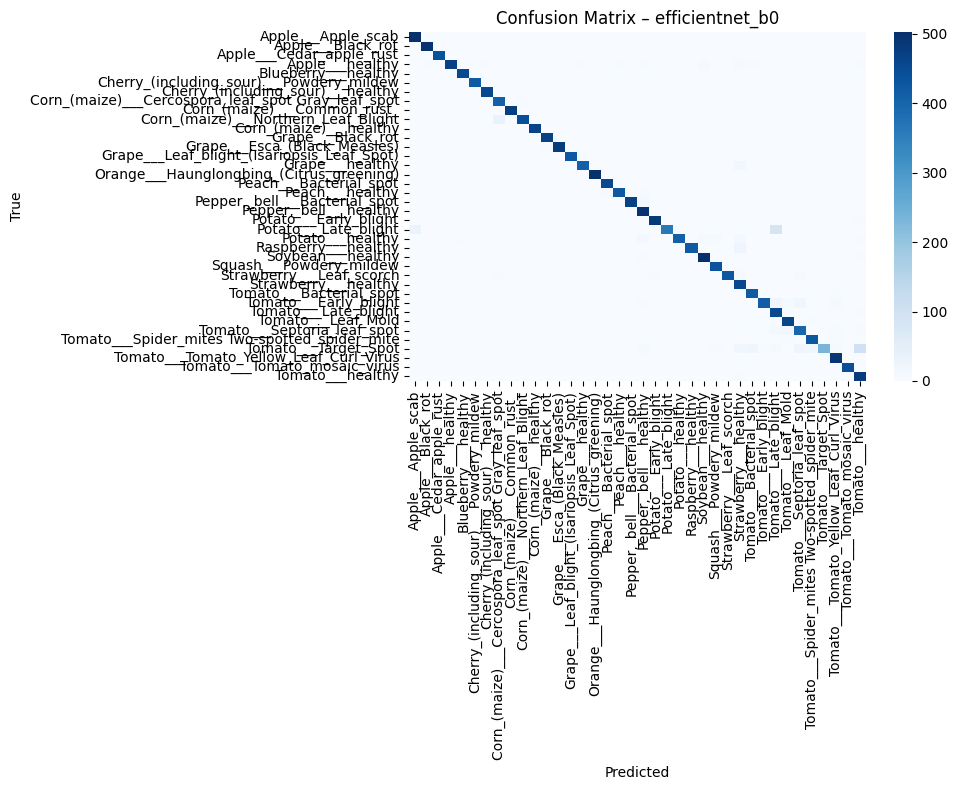

Creating model: vgg16 (pretrained=False)
Total parameters: 134,416,230
Trainable parameters: 134,416,230
[LOAD] vgg16 (best_acc: 92.05%)

------------- VGG16 -------------
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.8879    0.5972    0.7141       504
                                 Apple___Black_rot     0.8828    0.9396    0.9103       497
                          Apple___Cedar_apple_rust     0.9292    0.4773    0.6306       440
                                   Apple___healthy     0.7849    0.6614    0.7178       502
                               Blueberry___healthy     0.9023    0.8546    0.8778       454
          Cherry_(including_sour)___Powdery_mildew     0.7757    0.6817    0.7257       421
                 Cherry_(including_sour)___healthy     0.9241    0.9342    0.9291       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.4973    0.8951    0.6394       410

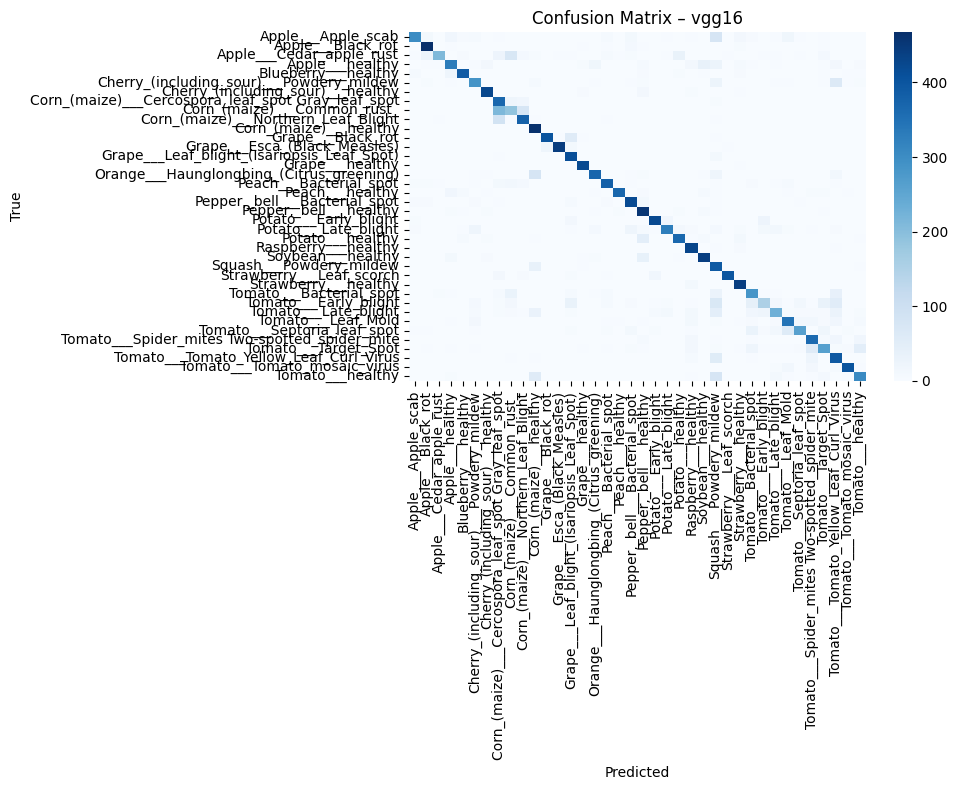

In [ ]:
import os, yaml, torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from src.models.classifier import create_model
from src.preprocessing.dataloader import create_dataloaders
from src.augmentation.policies import get_train_transforms, get_valid_transforms
from src.utils import set_seed

set_seed(42)

# Priprema okruzenja i podataka
device = "cuda" if torch.cuda.is_available() else "cpu"
with open("config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

policy = config["augmentation"].get("policy", "medium")
train_transform = get_train_transforms(config, policy=policy)
valid_transform = get_valid_transforms(config)
loaders = create_dataloaders(
    config,
    train_transform=train_transform,
    valid_transform=valid_transform,
    use_weighted_sampling=False,
    seed=42,
)

# Koristi validacioni skup za metrike (ako nema valid, pada na test ili train)
eval_loader = loaders.get("valid") or loaders.get("test") or loaders["train"]

# Imena klasa
train_path = os.path.join(config["dataset"]["root_dir"], "train")
class_names = sorted(
    d for d in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, d))
)
num_classes = len(class_names)

MODELS = ["resnet18", "resnet50", "efficientnet_b0", "vgg16"]


def load_model(model_name):
    model_path = f"outputs/{model_name}/best_model.pth"
    if not os.path.exists(model_path):
        print(f"[SKIP] {model_name}: ne postoji {model_path}")
        return None
    checkpoint = torch.load(model_path, map_location=device)
    state_dict = checkpoint.get("model_state_dict", checkpoint)
    model = create_model(num_classes=num_classes, model_name=model_name, pretrained=False)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    best_acc = checkpoint.get("best_acc", None)
    if best_acc is not None:
        print(f"[LOAD] {model_name} (best_acc: {best_acc:.2f}%)")
    else:
        print(f"[LOAD] {model_name}")
    return model


def collect_preds(model, loader):
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            y_true.append(yb.cpu())
            y_pred.append(preds.cpu())
    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()
    return y_true, y_pred


for name in MODELS:
    model = load_model(name)
    if model is None:
        continue

    y_true, y_pred = collect_preds(model, eval_loader)

    print(f"\n------------- {name.upper()} -------------")
    print(classification_report(
        y_true, y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    ))

    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_df, annot=False, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


### Evaluacija modela na validacionom skupu

#### Sta znace metrike u tabeli

- **Precision (preciznost)**  
  Od svih slika koje je model **predvidio** kao neku klasu, koliko je zaista tacno.  
  Formula: `TP / (TP + FP)`  
  Visoka precision znaci da ima malo laznih predvidjanja za tu klasu.

- **Recall (odziv)**  
  Od svih slika koje **stvarno pripadaju** klasi, koliko ih je model uspeo da prepozna.  
  Formula: `TP / (TP + FN)`  
  Visok recall znaci da model rijetko promasi tu klasu.

- **F1-score**  
  Harmonijska sredina precision i recall.  
  Formula: `2 * (P * R) / (P + R)`  
  Koristi se kada hocemo balans izmedju precision i recall (korisno kod nejednakih klasa).

- **Support**  
  Broj stvarnih uzoraka te klase u evaluacionom skupu (koliko slika klase je model testiran).

- **Accuracy**  
  Ukupan procenat tacnih predikcija preko svih klasa.

- **Macro avg**  
  Prosjek metrika po klasama, sve klase imaju istu tezinu.

- **Weighted avg**  
  Prosjek metrika po klasama, ali ponderisan po `support` (vise uzoraka znaci veci uticaj).

### Rezultati (accuracy na valid)

- **ResNet18:** **96.15%**
- **ResNet50:** **96.03%**
- **EfficientNet-B0:** **95.94%**
- **VGG16:** **78.00%**

### Matrice konfuzije

#### ResNet18
- Jaka, tamna dijagonala skoro kroz cijelu matricu sto znaci veliki broj tacnih klasifikacija.
- Greske su najcesce u vizuelno slicnim klasama.

#### ResNet50
- Vrlo slican obrazac kao ResNet18, dominantna dijagonala i malo elemenata van nje.
- Ukupno i dalje vrlo stabilan model sa malim brojem gresaka.

#### EfficientNet-B0
- Takodje izrazeno tamna dijagonala, uz nekoliko lokalnih gresaka.
- Dobre performanse i konzistentnost kroz vecinu klasa.

#### VGG16
- Dijagonala je znatno slabija, a van dijagonale ima vise.
- Vidi se rasipanje predikcija u vise susjednih ili slicnih klasa.
- Ovo potvrdjuje nizi accuracy/F1.

### Zakljucak

- **ResNet18, ResNet50 i EfficientNet-B0** su vrlo bliski i stabilni po precision, recall, F1 i matrici konfuzije.
- **VGG16** znacajno zaostaje, sto potvrdjuje da je losiji izbor za ovaj rad.
- Klase koje su vizuelno slicne i dalje su najteze, sto se vidi kroz nizi recall, F1 i matricu konfuzije.